# 07. Predicción probabilística de sequías mediante simulación Monte Carlo (nSPEI-3)

Versión corregida y trazable con los resultados definitivos de los Bloques 03 y 04.

Este cuaderno genera escenarios sintéticos de duración y severidad para nSPEI-3 mediante 20 000 realizaciones por cluster.

Modelos finales utilizados:

- Cluster 1: duración LN3, severidad LN3, cópula Gaussiana.
- Cluster 2: duración LN3, severidad LN3, cópula Gumbel.
- Cluster 3: duración LN3, severidad GPA, cópula Gumbel.

El procedimiento es:

$$
(U_i,V_i)\sim C_{\hat\theta},
$$

$$
D_i^\ast = F_D^{-1}(U_i), \qquad
S_i^\ast = F_S^{-1}(V_i).
$$

La simulación Monte Carlo no pronostica la fecha futura de una sequía. Genera realizaciones compatibles con la estructura probabilística estimada a partir de los eventos históricos.

Los momentos-L no se reestiman en este bloque. Se usan directamente los parámetros MLE definitivos guardados por el Bloque 03 y las cópulas seleccionadas por el Bloque 04.


In [70]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  janitor,
  lmomco,
  copula,
  patchwork,
  scales
)


In [71]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

encontrar_raiz_proyecto <- function(inicio = getwd()) {
  marcadores <- c("01_datos", "02_scripts", "03_resultados", "04_documentacion")
  es_raiz <- function(x) all(dir.exists(file.path(x, marcadores)))

  raiz_env <- Sys.getenv("TESIS_SEQUIAS_ROOT", unset = "")
  if (nzchar(raiz_env)) {
    raiz_env <- normalizePath(raiz_env, winslash = "/", mustWork = FALSE)
    if (es_raiz(raiz_env)) return(raiz_env)
  }

  ruta <- normalizePath(inicio, winslash = "/", mustWork = TRUE)

  repeat {
    if (es_raiz(ruta)) return(ruta)

    padre <- dirname(ruta)
    if (identical(padre, ruta)) {
      stop(
        "No se encontró la raíz del proyecto. ",
        "Ejecute Jupyter dentro del repositorio o defina TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_procesados <- file.path(
  ruta_base, "01_datos", "procesados"
)

ruta_marginales <- file.path(
  ruta_base, "03_resultados", "03_marginales", "tablas"
)

ruta_copulas <- file.path(
  ruta_base, "03_resultados", "04_copulas", "tablas"
)

ruta_tablas <- file.path(
  ruta_base, "03_resultados", "07_montecarlo", "tablas"
)

ruta_figuras <- file.path(
  ruta_base, "03_resultados", "07_montecarlo", "figuras"
)

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)

archivo_marginales <- file.path(
  ruta_marginales,
  "mejores_marginales_nspei3_por_cluster.csv"
)

archivo_copulas <- file.path(
  ruta_copulas,
  "copulas_seleccionadas_nspei3.csv"
)

dir.create(ruta_tablas, recursive = TRUE, showWarnings = FALSE)
dir.create(ruta_figuras, recursive = TRUE, showWarnings = FALSE)

cat("Eventos:", file.exists(archivo_eventos), "\n")
cat("Marginales:", file.exists(archivo_marginales), "\n")
cat("Cópulas:", file.exists(archivo_copulas), "\n")
cat("Ruta tablas:", ruta_tablas, "\n")
cat("Ruta figuras:", ruta_figuras, "\n")

if (!file.exists(archivo_eventos)) {
  stop("No se encontró el archivo de eventos.")
}

if (!file.exists(archivo_marginales)) {
  stop("No se encontró el archivo de marginales finales del Bloque 03.")
}

if (!file.exists(archivo_copulas)) {
  stop("No se encontró el archivo de cópulas seleccionadas del Bloque 04.")
}


Eventos: TRUE 
Marginales: TRUE 
Cópulas: TRUE 
Ruta tablas: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/07_montecarlo/tablas 
Ruta figuras: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/07_montecarlo/figuras 


In [72]:
# ============================================================
# 3. LECTURA Y VERIFICACIÓN DE MODELOS FINALES
# ============================================================

eventos <- read.csv(
  archivo_eventos,
  stringsAsFactors = FALSE
) %>%
  clean_names() %>%
  mutate(
    fecha_inicio = as.Date(fecha_inicio),
    fecha_fin = as.Date(fecha_fin),
    cluster_ward = as.integer(cluster_ward)
  )

eventos_3 <- eventos %>%
  filter(escala == "nspei_3") %>%
  filter(
    is.finite(duracion),
    is.finite(severidad),
    duracion > 0,
    severidad > 0
  )

marginales_finales <- read.csv(
  archivo_marginales,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(stringr::str_extract(grupo, "\\d+")),
    variable_clave = if_else(
      stringr::str_detect(variable, regex("Duraci", ignore_case = TRUE)),
      "D",
      "S"
    ),
    modelo = toupper(modelo)
  )

copulas_finales <- read.csv(
  archivo_copulas,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(cluster),
    familia = as.character(familia)
  )

esperado_marginal <- tibble(
  cluster = c(1, 1, 2, 2, 3, 3),
  variable_clave = c("D", "S", "D", "S", "D", "S"),
  modelo_esperado = c("LN3", "LN3", "LN3", "LN3", "LN3", "GPA")
)

verificacion_marginal <- marginales_finales %>%
  select(cluster, variable_clave, modelo) %>%
  left_join(
    esperado_marginal,
    by = c("cluster", "variable_clave")
  ) %>%
  mutate(
    coincide = modelo == modelo_esperado
  )

esperado_copula <- tibble(
  cluster = 1:3,
  familia_esperada = c("Gaussian", "Gumbel", "Gumbel")
)

verificacion_copula <- copulas_finales %>%
  select(cluster, familia, convergio, coincide_aic_bic) %>%
  left_join(
    esperado_copula,
    by = "cluster"
  ) %>%
  mutate(
    coincide = familia == familia_esperada
  )

cat("\n=== VERIFICACIÓN DE MARGINALES ===\n")
print(verificacion_marginal)

cat("\n=== VERIFICACIÓN DE CÓPULAS ===\n")
print(verificacion_copula)

if (any(is.na(verificacion_marginal$coincide) | !verificacion_marginal$coincide)) {
  stop("Las marginales no coinciden con los resultados definitivos del Bloque 03.")
}

if (
  any(is.na(verificacion_copula$coincide) | !verificacion_copula$coincide) ||
  any(!verificacion_copula$convergio) ||
  any(!verificacion_copula$coincide_aic_bic)
) {
  stop("Las cópulas no coinciden con los resultados definitivos del Bloque 04.")
}



=== VERIFICACIÓN DE MARGINALES ===
  cluster variable_clave modelo modelo_esperado coincide
1       1              D    LN3             LN3     TRUE
2       1              S    LN3             LN3     TRUE
3       2              D    LN3             LN3     TRUE
4       2              S    LN3             LN3     TRUE
5       3              D    LN3             LN3     TRUE
6       3              S    GPA             GPA     TRUE

=== VERIFICACIÓN DE CÓPULAS ===
  cluster  familia convergio coincide_aic_bic familia_esperada coincide
1       1 Gaussian      TRUE             TRUE         Gaussian     TRUE
2       2   Gumbel      TRUE             TRUE           Gumbel     TRUE
3       3   Gumbel      TRUE             TRUE           Gumbel     TRUE


In [73]:
# ============================================================
# 4. RECONSTRUCCIÓN DE MARGINALES Y CÓPULAS
# ============================================================

parsear_parametros_marginal <- function(x) {
  as.numeric(trimws(strsplit(x, ",", fixed = TRUE)[[1]]))
}

obtener_marginal <- function(cluster, variable_clave) {

  fila <- marginales_finales %>%
    filter(
      .data$cluster == .env$cluster,
      .data$variable_clave == .env$variable_clave
    )

  if (nrow(fila) != 1) {
    stop(
      "No se encontró exactamente una marginal para cluster ",
      cluster, " y variable ", variable_clave
    )
  }

  tipo <- tolower(fila$modelo[[1]])
  pars <- parsear_parametros_marginal(fila$parametros[[1]])

  list(
    modelo = toupper(tipo),
    parametros = pars,
    par_obj = lmomco::vec2par(pars, type = tipo)
  )
}

parsear_parametros_copula <- function(x) {

  piezas <- strsplit(x, ";", fixed = TRUE)[[1]]

  valores <- vapply(
    piezas,
    function(z) {
      partes <- strsplit(z, "=", fixed = TRUE)[[1]]
      if (length(partes) < 2) return(NA_real_)
      as.numeric(trimws(partes[length(partes)]))
    },
    numeric(1)
  )

  if (any(!is.finite(valores))) {
    stop("No se pudieron interpretar los parámetros de la cópula: ", x)
  }

  valores
}

obtener_copula <- function(cluster) {

  fila <- copulas_finales %>%
    filter(.data$cluster == .env$cluster)

  if (nrow(fila) != 1) {
    stop("No se encontró exactamente una cópula para el cluster ", cluster)
  }

  familia <- fila$familia[[1]]
  pars <- parsear_parametros_copula(fila$parametro[[1]])

  cop <- switch(
    tolower(familia),

    "gaussian" = normalCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un"
    ),

    "gumbel" = gumbelCopula(
      param = pars[1],
      dim = 2
    ),

    "clayton" = claytonCopula(
      param = pars[1],
      dim = 2
    ),

    "frank" = frankCopula(
      param = pars[1],
      dim = 2
    ),

    "t-student" = tCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un",
      df = pars[2],
      df.fixed = TRUE
    ),

    stop("Familia de cópula no implementada: ", familia)
  )

  list(
    familia = familia,
    parametro_texto = fila$parametro[[1]],
    parametros = pars,
    copula = cop
  )
}

modelos_cluster <- lapply(
  1:3,
  function(cl) {
    list(
      cluster = cl,
      D = obtener_marginal(cl, "D"),
      S = obtener_marginal(cl, "S"),
      C = obtener_copula(cl)
    )
  }
)

tabla_modelos_finales <- map_dfr(
  modelos_cluster,
  function(m) {
    tibble(
      cluster = m$cluster,
      marginal_duracion = m$D$modelo,
      marginal_severidad = m$S$modelo,
      copula = m$C$familia,
      parametro_copula = m$C$parametro_texto
    )
  }
)

cat("\n=== MODELOS FINALES UTILIZADOS ===\n")
print(tabla_modelos_finales, n = Inf, width = Inf)



=== MODELOS FINALES UTILIZADOS ===
# A tibble: 3 × 5
  cluster marginal_duracion marginal_severidad copula   parametro_copula
    <int> <chr>             <chr>              <chr>    <chr>           
1       1 LN3               LN3                Gaussian rho.1=0.903663  
2       2 LN3               LN3                Gumbel   alpha=3.456922  
3       3 LN3               GPA                Gumbel   alpha=3.801567  


In [74]:
# ============================================================
# 5. INVERSA MARGINAL NUMÉRICA
# ============================================================

# Se conserva la lógica metodológica de inversión numérica, pero usando
# los parámetros MLE definitivos del Bloque 03.
#
# La malla se expande automáticamente hasta cubrir probabilidades muy
# próximas a 1. Esto evita truncar artificialmente la cola superior.

construir_inversa_marginal <- function(
  par_obj,
  x_obs,
  eps = 1e-8,
  n_grid = 30000
) {

  x_obs <- as.numeric(x_obs)
  x_obs <- x_obs[is.finite(x_obs) & x_obs > 0]

  if (length(x_obs) == 0) {
    stop("No hay observaciones válidas para construir la inversa marginal.")
  }

  xmin <- 0
  xmax <- max(x_obs, na.rm = TRUE) * 2

  for (i in 1:12) {
    pmax_eval <- suppressWarnings(
      lmomco::plmomco(xmax, par_obj)
    )

    if (
      is.finite(pmax_eval) &&
      pmax_eval >= 1 - eps
    ) {
      break
    }

    xmax <- xmax * 1.8
  }

  xgrid <- seq(
    xmin,
    xmax,
    length.out = n_grid
  )

  pgrid <- suppressWarnings(
    lmomco::plmomco(xgrid, par_obj)
  )

  ok <- is.finite(pgrid) & !is.na(pgrid)
  xgrid <- xgrid[ok]
  pgrid <- pgrid[ok]

  ord <- order(pgrid)
  pgrid <- pgrid[ord]
  xgrid <- xgrid[ord]

  keep <- !duplicated(pgrid)
  pgrid <- pgrid[keep]
  xgrid <- xgrid[keep]

  if (length(pgrid) < 100) {
    stop("La malla de inversión marginal es insuficiente.")
  }

  function(u) {

    u <- pmin(
      pmax(u, max(eps, min(pgrid))),
      min(1 - eps, max(pgrid))
    )

    approx(
      x = pgrid,
      y = xgrid,
      xout = u,
      rule = 2,
      ties = "ordered"
    )$y
  }
}

datos_clusters <- lapply(
  1:3,
  function(cl) {
    eventos_3 %>%
      filter(cluster_ward == cl)
  }
)

inversas_cluster <- lapply(
  1:3,
  function(cl) {

    list(
      inv_D = construir_inversa_marginal(
        modelos_cluster[[cl]]$D$par_obj,
        datos_clusters[[cl]]$duracion
      ),
      inv_S = construir_inversa_marginal(
        modelos_cluster[[cl]]$S$par_obj,
        datos_clusters[[cl]]$severidad
      )
    )
  }
)

cat("Funciones inversas marginales construidas correctamente.\n")


Funciones inversas marginales construidas correctamente.


In [75]:
# ============================================================
# 6. SIMULACIÓN MONTE CARLO
# ============================================================

simular_cluster_mc <- function(
  datos_cluster,
  cluster_id,
  modelo_cluster,
  inversas,
  n_sim = 20000,
  semilla = 123
) {

  set.seed(semilla)

  uv <- copula::rCopula(
    n_sim,
    modelo_cluster$C$copula
  )

  d_cont <- inversas$inv_D(uv[, 1])
  s_sim <- inversas$inv_S(uv[, 2])

  if (
    any(!is.finite(d_cont)) ||
    any(!is.finite(s_sim))
  ) {
    stop("La simulación produjo valores no finitos.")
  }

  if (
    any(d_cont <= 0) ||
    any(s_sim <= 0)
  ) {
    stop("La simulación produjo valores no positivos.")
  }

  tibble(
    cluster = cluster_id,
    u = uv[, 1],
    v = uv[, 2],

    # Salida continua del modelo probabilístico.
    duracion_sim_continua = d_cont,

    # Duración expresada físicamente en meses enteros.
    # Se conserva también la versión continua para no alterar el modelo.
    duracion_sim_meses = pmax(1, round(d_cont)),

    severidad_sim = s_sim
  )
}

N_SIM <- 20000
SEMILLAS <- c(101, 102, 103)

simulaciones <- lapply(
  1:3,
  function(cl) {
    simular_cluster_mc(
      datos_cluster = datos_clusters[[cl]],
      cluster_id = cl,
      modelo_cluster = modelos_cluster[[cl]],
      inversas = inversas_cluster[[cl]],
      n_sim = N_SIM,
      semilla = SEMILLAS[cl]
    )
  }
)

sim_c1 <- simulaciones[[1]]
sim_c2 <- simulaciones[[2]]
sim_c3 <- simulaciones[[3]]

sim_all <- bind_rows(simulaciones)

write.csv(
  sim_all,
  file.path(
    ruta_tablas,
    "simulacion_montecarlo_nspei3_tres_clusters.csv"
  ),
  row.names = FALSE
)

cat("\n=== NÚMERO DE REALIZACIONES ===\n")
print(
  sim_all %>%
    count(cluster, name = "n_sim")
)



=== NÚMERO DE REALIZACIONES ===
# A tibble: 3 × 2
  cluster n_sim
    <int> <int>
1       1 20000
2       2 20000
3       3 20000


In [76]:
# ============================================================
# 7. FUNCIONES DE VALIDACIÓN Y RESUMEN
# ============================================================

cdf_marginal <- function(x, par_obj, eps = 1e-8) {
  p <- suppressWarnings(
    lmomco::plmomco(x, par_obj)
  )

  if (any(!is.finite(p))) {
    stop("Se obtuvieron valores no finitos en una CDF marginal.")
  }

  pmin(pmax(p, eps), 1 - eps)
}

probabilidad_conjunta_modelo <- function(
  d,
  s,
  modelo_cluster
) {

  u <- cdf_marginal(
    d,
    modelo_cluster$D$par_obj
  )

  v <- cdf_marginal(
    s,
    modelo_cluster$S$par_obj
  )

  Cuv <- copula::pCopula(
    cbind(u, v),
    modelo_cluster$C$copula
  )

  p_joint <- 1 - u - v + Cuv

  pmin(pmax(p_joint, 0), 1)
}

resumen_mc_cluster <- function(
  sim_df,
  datos_cluster,
  modelo_cluster
) {

  p50_d <- as.numeric(
    quantile(datos_cluster$duracion, 0.50, na.rm = TRUE, type = 7)
  )
  p75_d <- as.numeric(
    quantile(datos_cluster$duracion, 0.75, na.rm = TRUE, type = 7)
  )
  p90_d <- as.numeric(
    quantile(datos_cluster$duracion, 0.90, na.rm = TRUE, type = 7)
  )

  p50_s <- as.numeric(
    quantile(datos_cluster$severidad, 0.50, na.rm = TRUE, type = 7)
  )
  p75_s <- as.numeric(
    quantile(datos_cluster$severidad, 0.75, na.rm = TRUE, type = 7)
  )
  p90_s <- as.numeric(
    quantile(datos_cluster$severidad, 0.90, na.rm = TRUE, type = 7)
  )

  p_joint_p75_teor <- probabilidad_conjunta_modelo(
    p75_d,
    p75_s,
    modelo_cluster
  )

  p_joint_p90_teor <- probabilidad_conjunta_modelo(
    p90_d,
    p90_s,
    modelo_cluster
  )

  p_joint_p75_mc <- mean(
    sim_df$duracion_sim_continua > p75_d &
      sim_df$severidad_sim > p75_s
  )

  p_joint_p90_mc <- mean(
    sim_df$duracion_sim_continua > p90_d &
      sim_df$severidad_sim > p90_s
  )

  tau_observado <- suppressWarnings(
    cor(
      datos_cluster$duracion,
      datos_cluster$severidad,
      method = "kendall",
      use = "complete.obs"
    )
  )

  tau_simulado <- suppressWarnings(
    cor(
      sim_df$duracion_sim_continua,
      sim_df$severidad_sim,
      method = "kendall",
      use = "complete.obs"
    )
  )

  tau_modelo <- as.numeric(
    copula::tau(modelo_cluster$C$copula)
  )

  tibble(
    n_sim = nrow(sim_df),

    D_media = mean(sim_df$duracion_sim_continua),
    D_mediana = median(sim_df$duracion_sim_continua),
    D_p05 = as.numeric(quantile(sim_df$duracion_sim_continua, 0.05)),
    D_p95 = as.numeric(quantile(sim_df$duracion_sim_continua, 0.95)),

    S_media = mean(sim_df$severidad_sim),
    S_mediana = median(sim_df$severidad_sim),
    S_p05 = as.numeric(quantile(sim_df$severidad_sim, 0.05)),
    S_p95 = as.numeric(quantile(sim_df$severidad_sim, 0.95)),

    P_D_gt_P50 = mean(sim_df$duracion_sim_continua > p50_d),
    P_D_gt_P75 = mean(sim_df$duracion_sim_continua > p75_d),
    P_D_gt_P90 = mean(sim_df$duracion_sim_continua > p90_d),

    P_S_gt_P50 = mean(sim_df$severidad_sim > p50_s),
    P_S_gt_P75 = mean(sim_df$severidad_sim > p75_s),
    P_S_gt_P90 = mean(sim_df$severidad_sim > p90_s),

    P_joint_P75_MC = p_joint_p75_mc,
    P_joint_P75_modelo = p_joint_p75_teor,
    error_MC_P75 = p_joint_p75_mc - p_joint_p75_teor,

    P_joint_P90_MC = p_joint_p90_mc,
    P_joint_P90_modelo = p_joint_p90_teor,
    error_MC_P90 = p_joint_p90_mc - p_joint_p90_teor,

    tau_observado = tau_observado,
    tau_simulado = tau_simulado,
    tau_modelo = tau_modelo
  )
}


In [77]:
# ============================================================
# 8. RESUMEN ESTADÍSTICO Y VALIDACIÓN MONTE CARLO
# ============================================================

resumen_mc <- map_dfr(
  1:3,
  function(cl) {

    resumen_mc_cluster(
      simulaciones[[cl]],
      datos_clusters[[cl]],
      modelos_cluster[[cl]]
    ) %>%
      mutate(
        cluster = cl,
        marginal_D = modelos_cluster[[cl]]$D$modelo,
        marginal_S = modelos_cluster[[cl]]$S$modelo,
        copula = modelos_cluster[[cl]]$C$familia,
        .before = 1
      )
  }
)

tabla_19 <- resumen_mc %>%
  transmute(
    cluster,
    n_sim,
    marginal_D,
    marginal_S,
    copula,
    D_media = round(D_media, 3),
    D_mediana = round(D_mediana, 3),
    D_p05 = round(D_p05, 3),
    D_p95 = round(D_p95, 3),
    S_media = round(S_media, 3),
    S_mediana = round(S_mediana, 3),
    S_p05 = round(S_p05, 3),
    S_p95 = round(S_p95, 3)
  )

write.csv(
  tabla_19,
  file.path(
    ruta_tablas,
    "tabla_19_resumen_estadistico_montecarlo.csv"
  ),
  row.names = FALSE
)

cat("\n=== TABLA 19 - RESUMEN ESTADÍSTICO ===\n")
print(tabla_19, n = Inf, width = Inf)



=== TABLA 19 - RESUMEN ESTADÍSTICO ===
# A tibble: 3 × 13
  cluster n_sim marginal_D marginal_S copula   D_media D_mediana D_p05 D_p95
    <int> <int> <chr>      <chr>      <chr>      <dbl>     <dbl> <dbl> <dbl>
1       1 20000 LN3        LN3        Gaussian    6.90      5.84  2.19  15.2
2       2 20000 LN3        LN3        Gumbel      9.07      6.81  2.96  22.6
3       3 20000 LN3        GPA        Gumbel     16.4      11.7   4.27  45.2
  S_media S_mediana S_p05 S_p95
    <dbl>     <dbl> <dbl> <dbl>
1    6.77      5.10  1.73  17.6
2    8.8       5.98  2.05  24.7
3   15.2       9.75  2.79  45.2


In [78]:
# ============================================================
# 9. PROBABILIDADES DE EXCEDENCIA Y CONTROL DE ERROR MC
# ============================================================

tabla_20 <- resumen_mc %>%
  transmute(
    cluster,

    D50 = round(P_D_gt_P50, 5),
    D75 = round(P_D_gt_P75, 5),
    D90 = round(P_D_gt_P90, 5),

    S50 = round(P_S_gt_P50, 5),
    S75 = round(P_S_gt_P75, 5),
    S90 = round(P_S_gt_P90, 5),

    P_joint_P75_MC = round(P_joint_P75_MC, 5),
    P_joint_P75_modelo = round(P_joint_P75_modelo, 5),
    error_MC_P75 = round(error_MC_P75, 5),

    P_joint_P90_MC = round(P_joint_P90_MC, 5),
    P_joint_P90_modelo = round(P_joint_P90_modelo, 5),
    error_MC_P90 = round(error_MC_P90, 5)
  )

write.csv(
  tabla_20,
  file.path(
    ruta_tablas,
    "tabla_20_probabilidades_excedencia_montecarlo.csv"
  ),
  row.names = FALSE
)

cat("\n=== TABLA 20 - PROBABILIDADES DE EXCEDENCIA ===\n")
print(tabla_20, n = Inf, width = Inf)



=== TABLA 20 - PROBABILIDADES DE EXCEDENCIA ===
# A tibble: 3 × 13
  cluster   D50   D75    D90   S50   S75    S90 P_joint_P75_MC
    <int> <dbl> <dbl>  <dbl> <dbl> <dbl>  <dbl>          <dbl>
1       1 0.483 0.295 0.107  0.495 0.244 0.106           0.207
2       2 0.484 0.205 0.0880 0.508 0.239 0.0982          0.176
3       3 0.444 0.288 0.137  0.502 0.292 0.0887          0.242
  P_joint_P75_modelo error_MC_P75 P_joint_P90_MC P_joint_P90_modelo error_MC_P90
               <dbl>        <dbl>          <dbl>              <dbl>        <dbl>
1              0.207      0.00039         0.0750             0.0750     -0.00006
2              0.179     -0.0024          0.0730             0.0731     -0.00018
3              0.246     -0.0036          0.0836             0.0837     -0.00012


In [79]:
# ============================================================
# 10. CONSERVACIÓN DE LA DEPENDENCIA
# ============================================================

tabla_21 <- resumen_mc %>%
  transmute(
    cluster,
    copula,
    tau_observado = round(tau_observado, 4),
    tau_modelo = round(tau_modelo, 4),
    tau_simulado = round(tau_simulado, 4),
    diferencia_sim_modelo = round(tau_simulado - tau_modelo, 4)
  )

write.csv(
  tabla_21,
  file.path(
    ruta_tablas,
    "tabla_21_validacion_dependencia_montecarlo.csv"
  ),
  row.names = FALSE
)

cat("\n=== TABLA 21 - CONSERVACIÓN DE LA DEPENDENCIA ===\n")
print(tabla_21, n = Inf, width = Inf)



=== TABLA 21 - CONSERVACIÓN DE LA DEPENDENCIA ===
# A tibble: 3 × 6
  cluster copula   tau_observado tau_modelo tau_simulado diferencia_sim_modelo
    <int> <chr>            <dbl>      <dbl>        <dbl>                 <dbl>
1       1 Gaussian         0.746      0.718        0.717               -0.0016
2       2 Gumbel           0.755      0.711        0.704               -0.0062
3       3 Gumbel           0.781      0.737        0.731               -0.0064


In [80]:
# ============================================================
# 11. CLASIFICACIÓN DE ESCENARIOS
# ============================================================

clasificar_escenario <- function(
  sim_df,
  datos_cluster
) {

  p75_d <- as.numeric(
    quantile(datos_cluster$duracion, 0.75, na.rm = TRUE, type = 7)
  )
  p90_d <- as.numeric(
    quantile(datos_cluster$duracion, 0.90, na.rm = TRUE, type = 7)
  )

  p75_s <- as.numeric(
    quantile(datos_cluster$severidad, 0.75, na.rm = TRUE, type = 7)
  )
  p90_s <- as.numeric(
    quantile(datos_cluster$severidad, 0.90, na.rm = TRUE, type = 7)
  )

  sim_df %>%
    mutate(
      escenario = case_when(
        duracion_sim_continua > p90_d &
          severidad_sim > p90_s ~ "Extremo",

        duracion_sim_continua > p75_d &
          severidad_sim > p75_s ~ "Severo",

        TRUE ~ "Típico"
      )
    )
}

escenarios_all <- map2_dfr(
  simulaciones,
  datos_clusters,
  clasificar_escenario
)

tabla_22 <- escenarios_all %>%
  count(cluster, escenario, name = "n") %>%
  group_by(cluster) %>%
  mutate(
    proporcion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    escenario = factor(
      escenario,
      levels = c("Típico", "Severo", "Extremo")
    )
  ) %>%
  arrange(cluster, escenario)

write.csv(
  tabla_22,
  file.path(
    ruta_tablas,
    "tabla_22_clasificacion_escenarios_montecarlo.csv"
  ),
  row.names = FALSE
)

cat("\n=== TABLA 22 - CLASIFICACIÓN DE ESCENARIOS ===\n")
print(tabla_22, n = Inf, width = Inf)



=== TABLA 22 - CLASIFICACIÓN DE ESCENARIOS ===
# A tibble: 9 × 4
  cluster escenario     n proporcion
    <int> <fct>     <int>      <dbl>
1       1 Típico    15858     0.793 
2       1 Severo     2643     0.132 
3       1 Extremo    1499     0.0750
4       2 Típico    16473     0.824 
5       2 Severo     2068     0.103 
6       2 Extremo    1459     0.0730
7       3 Típico    15161     0.758 
8       3 Severo     3168     0.158 
9       3 Extremo    1671     0.0836


In [81]:
# ============================================================
# 12. ESTILO GRÁFICO PARA FIGURAS MONTE CARLO
# ============================================================

pacman::p_load(
  ggplot2,
  dplyr,
  tidyr,
  patchwork,
  scales
)

# ------------------------------------------------------------
# Colores sobrios por cluster
# ------------------------------------------------------------

pal_cluster <- c(
  "1" = "#315F7D",   # azul acero
  "2" = "#B36A36",   # cobre
  "3" = "#7A2948"    # vino
)

pal_cluster_fill <- c(
  "1" = "#C4D2DC",
  "2" = "#E4C2A9",
  "3" = "#D5B1C0"
)

# Clasificación de escenarios
pal_escenario <- c(
  "Típico"  = "#D4DDE3",
  "Severo"  = "#D48654",
  "Extremo" = "#8D1F30"
)

nombre_copula_es <- function(x) {
  dplyr::case_when(
    x == "Gaussian"  ~ "Gaussiana",
    x == "Gumbel"    ~ "Gumbel",
    x == "Clayton"   ~ "Clayton",
    x == "Frank"     ~ "Frank",
    x == "t-Student" ~ "t de Student",
    TRUE ~ x
  )
}

# ------------------------------------------------------------
# Tema general
# ------------------------------------------------------------

theme_q1 <- function(base_size = 12) {

  theme_minimal(base_size = base_size) +

    theme(

      plot.title = element_text(
        face = "bold",
        size = 15,
        hjust = 0.5,
        margin = margin(b = 5)
      ),

      plot.subtitle = element_text(
        size = 10.5,
        colour = "#505050",
        hjust = 0.5,
        margin = margin(b = 9)
      ),

      axis.title = element_text(
        face = "bold",
        size = 11.5
      ),

      axis.text = element_text(
        size = 10,
        colour = "#303030"
      ),

      strip.text = element_text(
        face = "bold",
        size = 11
      ),

      panel.grid.major = element_line(
        colour = "#E2E2E2",
        linewidth = 0.32
      ),

      panel.grid.minor = element_blank(),

      panel.border = element_rect(
        colour = "#BEBEBE",
        fill = NA,
        linewidth = 0.4
      ),

      legend.title = element_text(
        face = "bold"
      ),

      legend.position = "bottom",

      plot.background = element_rect(
        fill = "white",
        colour = NA
      ),

      panel.background = element_rect(
        fill = "white",
        colour = NA
      )
    )
}

Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"
Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"
Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"


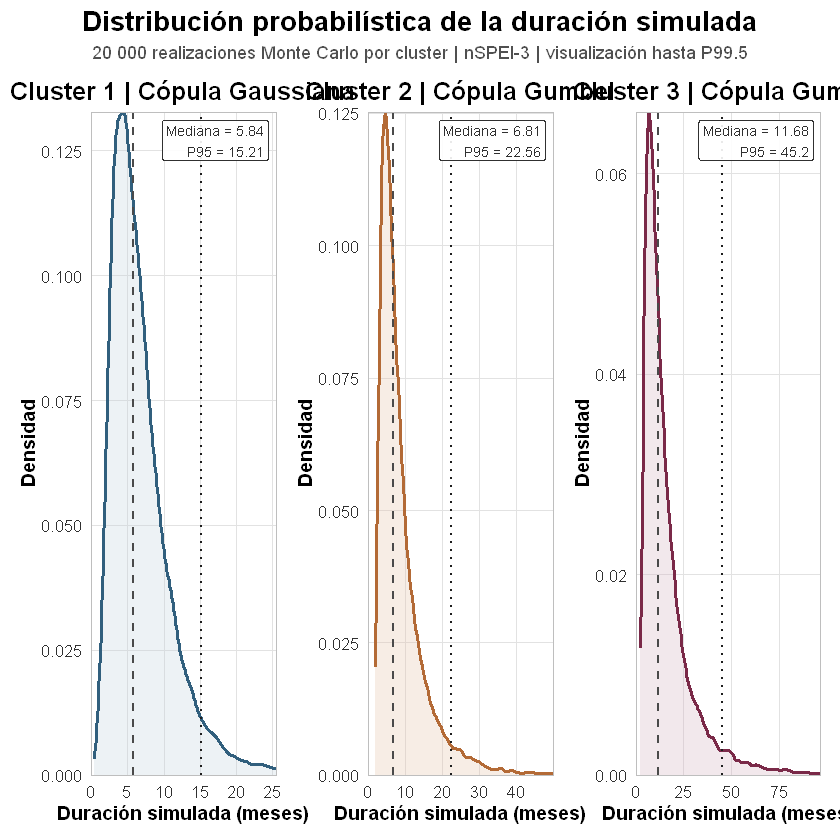

In [82]:
# ============================================================
# 13. FIGURA 23 - DISTRIBUCIÓN DE DURACIÓN SIMULADA
# ============================================================

plot_duracion_cluster <- function(cl) {

  datos <- sim_all %>%
    filter(cluster == cl)

  xmax <- quantile(
    datos$duracion_sim_continua,
    0.995,
    na.rm = TRUE
  )

  mediana <- median(
    datos$duracion_sim_continua,
    na.rm = TRUE
  )

  p95 <- quantile(
    datos$duracion_sim_continua,
    0.95,
    na.rm = TRUE
  )

  familia <- modelos_cluster[[cl]]$C$familia
  familia_es <- nombre_copula_es(familia)

  ggplot(
    datos,
    aes(
      x = duracion_sim_continua
    )
  ) +

    geom_density(
      aes(
        colour = factor(cl),
        fill = factor(cl)
      ),
      linewidth = 1.05,
      alpha = 0.30,
      adjust = 1.05
    ) +

    geom_vline(
      xintercept = mediana,
      colour = "#4A4A4A",
      linetype = "dashed",
      linewidth = 0.6
    ) +

    geom_vline(
      xintercept = p95,
      colour = "#1D1D1D",
      linetype = "dotted",
      linewidth = 0.7
    ) +

    annotate(
      "label",
      x = xmax * 0.96,
      y = Inf,
      label = paste0(
        "Mediana = ",
        round(mediana, 2),
        "\nP95 = ",
        round(p95, 2)
      ),
      hjust = 1,
      vjust = 1.2,
      size = 3.0,
      fill = alpha("white", 0.90),
      colour = "#303030",
      label.size = 0.2
    ) +

    scale_colour_manual(
      values = pal_cluster
    ) +

    scale_fill_manual(
      values = pal_cluster_fill
    ) +

    coord_cartesian(
      xlim = c(0, xmax),
      expand = FALSE
    ) +

    labs(
      title = paste0(
        "Cluster ",
        cl,
        " | Cópula ",
        familia_es
      ),
      x = "Duración simulada (meses)",
      y = "Densidad"
    ) +

    theme_q1() +

    theme(
      legend.position = "none"
    )
}

pD1 <- plot_duracion_cluster(1)
pD2 <- plot_duracion_cluster(2)
pD3 <- plot_duracion_cluster(3)

figura_23 <-
  (pD1 | pD2 | pD3) +

  plot_annotation(
    title =
      "Distribución probabilística de la duración simulada",

    subtitle =
      paste0(
        "20 000 realizaciones Monte Carlo por cluster | ",
        "nSPEI-3 | visualización hasta P99.5"
      ),

    theme = theme(
      plot.title = element_text(
        face = "bold",
        size = 16,
        hjust = 0.5
      ),

      plot.subtitle = element_text(
        size = 10.5,
        colour = "#505050",
        hjust = 0.5
      )
    )
  )

ggsave(
  file.path(
    ruta_figuras,
    "figura_23_distribucion_duracion_montecarlo.png"
  ),
  figura_23,
  width = 14.5,
  height = 5.2,
  dpi = 400,
  bg = "white"
)

figura_23

Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"
Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"
Warning message in annotate("label", x = xmax * 0.96, y = Inf, label = paste0("Mediana = ", :
"Ignoring unknown parameters: `label.size`"


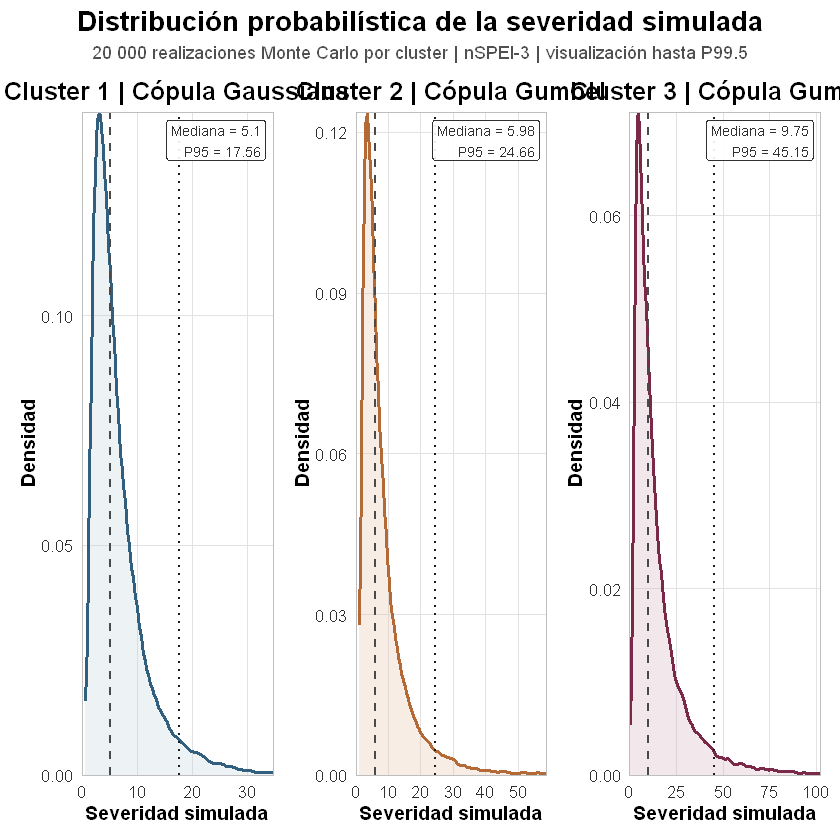

In [83]:
# ============================================================
# 14. FIGURA 24 - DISTRIBUCIÓN DE SEVERIDAD SIMULADA
# ============================================================

plot_severidad_cluster <- function(cl) {

  datos <- sim_all %>%
    filter(cluster == cl)

  xmax <- quantile(
    datos$severidad_sim,
    0.995,
    na.rm = TRUE
  )

  mediana <- median(
    datos$severidad_sim,
    na.rm = TRUE
  )

  p95 <- quantile(
    datos$severidad_sim,
    0.95,
    na.rm = TRUE
  )

  familia <- modelos_cluster[[cl]]$C$familia
  familia_es <- nombre_copula_es(familia)

  ggplot(
    datos,
    aes(
      x = severidad_sim
    )
  ) +

    geom_density(
      aes(
        colour = factor(cl),
        fill = factor(cl)
      ),
      linewidth = 1.05,
      alpha = 0.30,
      adjust = 1.05
    ) +

    geom_vline(
      xintercept = mediana,
      colour = "#4A4A4A",
      linetype = "dashed",
      linewidth = 0.6
    ) +

    geom_vline(
      xintercept = p95,
      colour = "#1D1D1D",
      linetype = "dotted",
      linewidth = 0.7
    ) +

    annotate(
      "label",
      x = xmax * 0.96,
      y = Inf,
      label = paste0(
        "Mediana = ",
        round(mediana, 2),
        "\nP95 = ",
        round(p95, 2)
      ),
      hjust = 1,
      vjust = 1.2,
      size = 3.0,
      fill = alpha("white", 0.90),
      colour = "#303030",
      label.size = 0.2
    ) +

    scale_colour_manual(
      values = pal_cluster
    ) +

    scale_fill_manual(
      values = pal_cluster_fill
    ) +

    coord_cartesian(
      xlim = c(0, xmax),
      expand = FALSE
    ) +

    labs(
      title = paste0(
        "Cluster ",
        cl,
        " | Cópula ",
        familia_es
      ),
      x = "Severidad simulada",
      y = "Densidad"
    ) +

    theme_q1() +

    theme(
      legend.position = "none"
    )
}

pS1 <- plot_severidad_cluster(1)
pS2 <- plot_severidad_cluster(2)
pS3 <- plot_severidad_cluster(3)

figura_24 <-
  (pS1 | pS2 | pS3) +

  plot_annotation(
    title =
      "Distribución probabilística de la severidad simulada",

    subtitle =
      paste0(
        "20 000 realizaciones Monte Carlo por cluster | ",
        "nSPEI-3 | visualización hasta P99.5"
      ),

    theme = theme(
      plot.title = element_text(
        face = "bold",
        size = 16,
        hjust = 0.5
      ),

      plot.subtitle = element_text(
        size = 10.5,
        colour = "#505050",
        hjust = 0.5
      )
    )
  )

ggsave(
  file.path(
    ruta_figuras,
    "figura_24_distribucion_severidad_montecarlo.png"
  ),
  figura_24,
  width = 14.5,
  height = 5.2,
  dpi = 400,
  bg = "white"
)

figura_24

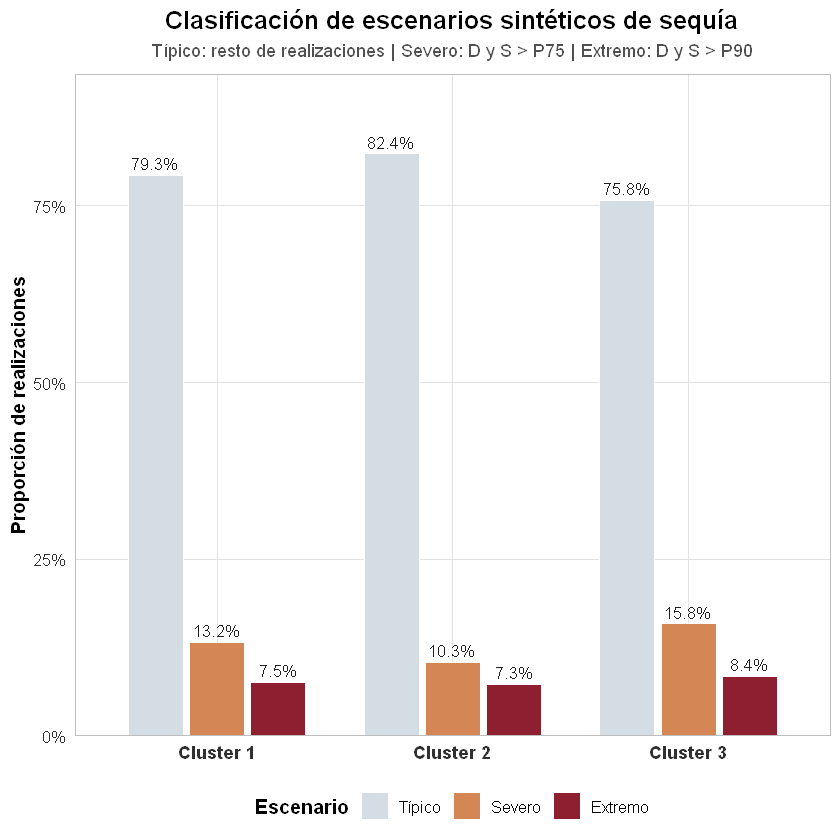

In [84]:
# ============================================================
# 15. FIGURA 25 - CLASIFICACIÓN DE ESCENARIOS
# ============================================================

tabla_plot_escenarios <- tabla_22 %>%

  mutate(

    cluster = factor(
      cluster,
      levels = c(1, 2, 3),
      labels = c(
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
      )
    ),

    escenario = factor(
      escenario,
      levels = c(
        "Típico",
        "Severo",
        "Extremo"
      )
    )
  )

figura_25 <-

  ggplot(
    tabla_plot_escenarios,
    aes(
      x = cluster,
      y = proporcion,
      fill = escenario
    )
  ) +

  geom_col(
    position = position_dodge(
      width = 0.78
    ),
    width = 0.70,
    colour = "white",
    linewidth = 0.4
  ) +

  geom_text(
    aes(
      label = percent(
        proporcion,
        accuracy = 0.1
      )
    ),
    position = position_dodge(
      width = 0.78
    ),
    vjust = -0.45,
    size = 3.5,
    colour = "#202020"
  ) +

  scale_fill_manual(
    values = pal_escenario
  ) +

  scale_y_continuous(
    labels = percent_format(
      accuracy = 1
    ),
    limits = c(0, 0.90),
    expand = expansion(
      mult = c(0, 0.04)
    )
  ) +

  labs(
    title =
      "Clasificación de escenarios sintéticos de sequía",

    subtitle =
      paste0(
        "Típico: resto de realizaciones | ",
        "Severo: D y S > P75 | ",
        "Extremo: D y S > P90"
      ),

    x = NULL,

    y =
      "Proporción de realizaciones",

    fill =
      "Escenario"
  ) +

  theme_q1() +

  theme(

    legend.position = "bottom",

    axis.text.x = element_text(
      face = "bold",
      size = 11
    )
  )

ggsave(
  file.path(
    ruta_figuras,
    "figura_25_proporcion_escenarios_montecarlo.png"
  ),
  figura_25,
  width = 11.5,
  height = 6.0,
  dpi = 400,
  bg = "white"
)

figura_25

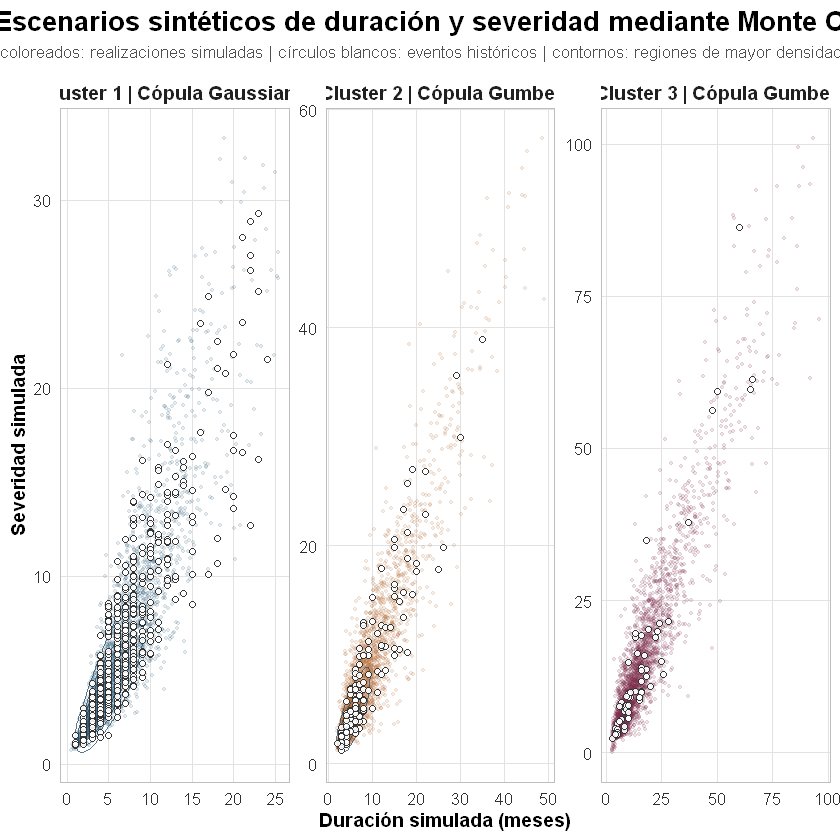

In [85]:
# ============================================================
# 16. FIGURA 26 - ESCENARIOS SINTÉTICOS DURACIÓN-SEVERIDAD
# ============================================================

set.seed(2026)

# ------------------------------------------------------------
# 1. LÍMITES P99.5 SOLO PARA VISUALIZACIÓN
# ------------------------------------------------------------

limites_plot <- sim_all %>%
  group_by(cluster) %>%
  summarise(
    D_lim = as.numeric(
      quantile(
        duracion_sim_continua,
        0.995,
        na.rm = TRUE
      )
    ),
    S_lim = as.numeric(
      quantile(
        severidad_sim,
        0.995,
        na.rm = TRUE
      )
    ),
    .groups = "drop"
  )


# ------------------------------------------------------------
# 2. SIMULACIONES DENTRO DEL RANGO VISUAL
# ------------------------------------------------------------

sim_visual <- sim_all %>%
  inner_join(
    limites_plot,
    by = "cluster"
  ) %>%
  filter(
    duracion_sim_continua <= D_lim,
    severidad_sim <= S_lim
  )


# ------------------------------------------------------------
# 3. MUESTRA PARA MOSTRAR LOS PUNTOS
#    Las 20 000 simulaciones siguen siendo utilizadas
#    para los análisis; aquí solo reducimos saturación visual.
# ------------------------------------------------------------

sim_plot <- sim_visual %>%
  group_by(cluster) %>%
  group_modify(
    ~ dplyr::slice_sample(
      .x,
      n = min(
        3000,
        nrow(.x)
      )
    )
  ) %>%
  ungroup()


# ------------------------------------------------------------
# 4. EVENTOS HISTÓRICOS
# ------------------------------------------------------------

obs_plot <- eventos_3 %>%
  transmute(
    cluster = cluster_ward,
    duracion = duracion,
    severidad = severidad
  ) %>%
  inner_join(
    limites_plot,
    by = "cluster"
  ) %>%
  filter(
    duracion <= D_lim,
    severidad <= S_lim
  )


# ------------------------------------------------------------
# 5. ETIQUETAS DE LOS PANELES
# ------------------------------------------------------------

etiquetas_cluster <- c(
  `1` = "Cluster 1 | Cópula Gaussiana",
  `2` = "Cluster 2 | Cópula Gumbel",
  `3` = "Cluster 3 | Cópula Gumbel"
)


# ------------------------------------------------------------
# 6. GRÁFICO
# ------------------------------------------------------------

figura_26 <- ggplot() +

  # ----------------------------------------------------------
  # Realizaciones Monte Carlo
  # ----------------------------------------------------------
  geom_point(
    data = sim_plot,
    aes(
      x = duracion_sim_continua,
      y = severidad_sim,
      colour = factor(cluster)
    ),
    alpha = 0.12,
    size = 0.70
  ) +

  # ----------------------------------------------------------
  # Contornos de densidad bivariada
  # Se calculan usando TODAS las simulaciones visibles,
  # no solamente la muestra de puntos.
  # ----------------------------------------------------------
  stat_density_2d(
    data = sim_visual,
    aes(
      x = duracion_sim_continua,
      y = severidad_sim,
      group = factor(cluster)
    ),
    bins = 6,
    colour = "#244A64",
    linewidth = 0.48,
    alpha = 0.75
  ) +

  # ----------------------------------------------------------
  # Eventos históricos
  # ----------------------------------------------------------
  geom_point(
    data = obs_plot,
    aes(
      x = duracion,
      y = severidad
    ),
    shape = 21,
    fill = "white",
    colour = "#1F1F1F",
    stroke = 0.48,
    size = 1.55,
    alpha = 0.90
  ) +

  # ----------------------------------------------------------
  # Paneles
  # ----------------------------------------------------------
  facet_wrap(
    ~cluster,
    scales = "free",
    nrow = 1,
    labeller = labeller(
      cluster = etiquetas_cluster
    )
  ) +

  scale_colour_manual(
    values = pal_cluster
  ) +

  labs(
    title =
      "Escenarios sintéticos de duración y severidad mediante Monte Carlo",

    subtitle =
      paste0(
        "Puntos coloreados: realizaciones simuladas | ",
        "círculos blancos: eventos históricos | ",
        "contornos: regiones de mayor densidad probabilística"
      ),

    x = "Duración simulada (meses)",
    y = "Severidad simulada",
    colour = NULL
  ) +

  theme_q1() +

  theme(
    legend.position = "none",

    strip.text = element_text(
      face = "bold",
      size = 11.5,
      colour = "#202020"
    ),

    plot.title = element_text(
      face = "bold",
      size = 16,
      hjust = 0.5
    ),

    plot.subtitle = element_text(
      size = 10.2,
      colour = "#505050",
      hjust = 0.5
    )
  )


# ------------------------------------------------------------
# 7. GUARDADO
# ------------------------------------------------------------

ggsave(
  file.path(
    ruta_figuras,
    "figura_26_escenarios_sinteticos_montecarlo.png"
  ),
  figura_26,
  width = 14.5,
  height = 5.5,
  dpi = 400,
  bg = "white"
)

figura_26